## Logistic Regression

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

In [2]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [3]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

In [4]:
C_VALUES = [5, 10, 20]
K_VALUES = range(1, 21)
TOP_N_VALUES = [50, 100, 250, 500, 1000]

sorted_features = feature_importance_df.sort_values("l1_rank")["feature"].values

all_results = []

for C in C_VALUES:
    print(f"Running: C={C}")

    for k in K_VALUES:
        
        for t in TOP_N_VALUES:

            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=10_000,
            )

            summary = cross_val_eval(
                model=model, X=X_sel, y=y_train, 
                n_features=k, model_name=f"logreg_C={C}_k={k}",
                top_n=t)

            summary["C"] = C

            all_results.append(summary)

final_results = pd.DataFrame(all_results)

Running: C=5
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 10
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 10
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 10
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 10
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 10
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 20
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 20
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 20
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 20
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 20
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 50
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 50
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 50
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 50
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 50
(4000, 1) (1000, 1) (4000,) (1000,)
effect

/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead 

(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 100
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 200
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 200
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 200
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 200
(4000, 1) (1000, 1) (4000,) (1000,)
effective top n chosen: 200
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 10
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 10
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 10
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 10
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 10
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 20
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 20
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 20
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 20
(4000, 2) (1000, 2) (4000,) (1000,)
effective top

/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead 

effective top n chosen: 50
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 50
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 50
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 50
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 50
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 100
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 100
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 100
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 100
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 100
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 200
(4000, 2) (1000, 2) (4000,) (1000,)
effective top n chosen: 200


...

/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead 

effective top n chosen: 20
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 20
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 20
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 50
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 50
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 50
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 50
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 50
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 100
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 100


/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead 

(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 100
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 100
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 100
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 200
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 200
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 200
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 200
(4000, 20) (1000, 20) (4000,) (1000,)
effective top n chosen: 200


/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/okrojekb/Filen/semester 8/AML/projects/Project_2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead 

In [5]:
final_results.sort_values(by="score", ascending=False).head(10)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,C
4,0.5304,0.570,0.229098,0.326833,710.0,510.0,1,0.021361,0.053502,0.021510,0.030683,160.507009,160.507009,logreg_C=5_k=1,None,1000,5
104,0.5304,0.570,0.229098,0.326833,710.0,510.0,1,0.021361,0.053502,0.021510,0.030683,160.507009,160.507009,logreg_C=10_k=1,None,1000,10
204,0.5304,0.570,0.229098,0.326833,710.0,510.0,1,0.021361,0.053502,0.021510,0.030683,160.507009,160.507009,logreg_C=20_k=1,None,1000,20
209,0.5452,0.607,0.243979,0.348058,821.0,421.0,2,0.021879,0.054153,0.021889,0.031176,162.457687,162.457687,logreg_C=20_k=2,None,1000,20
109,0.5452,0.607,0.243979,0.348058,821.0,421.0,2,0.021879,0.054153,0.021889,0.031176,162.457687,162.457687,logreg_C=10_k=2,None,1000,10
9,0.5448,0.606,0.243577,0.347485,818.0,418.0,2,0.021371,0.052844,0.021372,0.030435,158.532331,158.532331,logreg_C=5_k=2,None,1000,5
214,0.5628,0.651,0.261664,0.373288,953.0,353.0,3,0.018780,0.046287,0.018759,0.026698,138.861442,138.861442,logreg_C=20_k=3,None,1000,20
114,0.5624,0.650,0.261262,0.372714,950.0,350.0,3,0.019113,0.047170,0.019103,0.027193,141.509717,141.509717,logreg_C=10_k=3,None,1000,10
14,0.5616,0.648,0.260458,0.371568,944.0,344.0,3,0.019578,0.048296,0.019563,0.027846,144.887888,144.887888,logreg_C=5_k=3,None,1000,5
219,0.5732,0.677,0.272111,0.388193,1031.0,231.0,4,0.014096,0.034749,0.014086,0.020046,104.247302,104.247302,logreg_C=20_k=4,None,1000,20


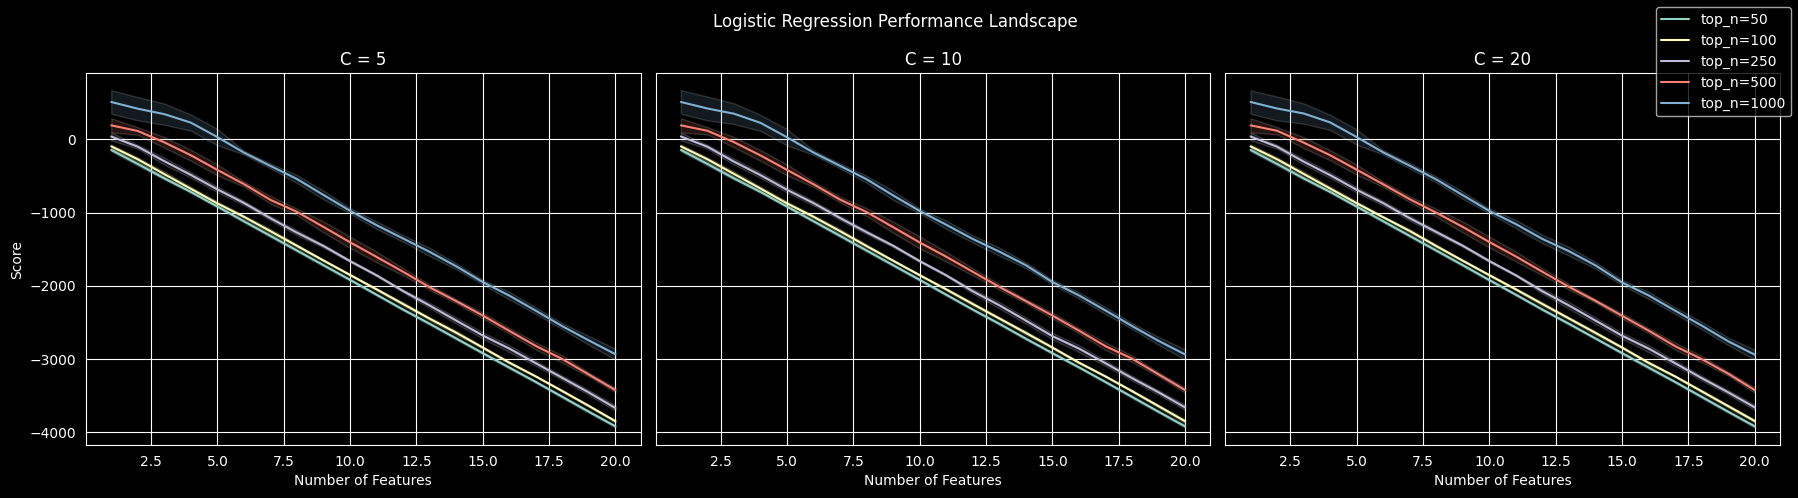

In [6]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="C",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)